In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from environments.utils.funcionesEMS import *
from environments.EMS_env import MicrogridEnv

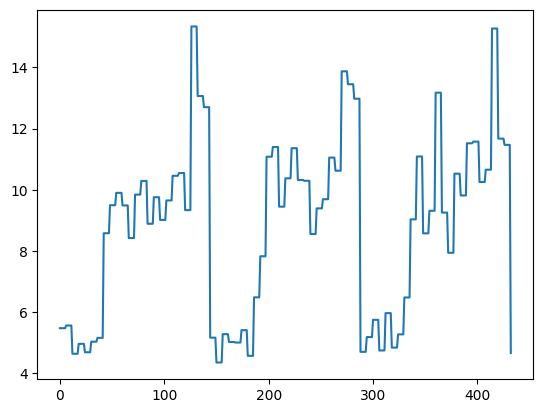

In [18]:
mg_env = MicrogridEnv()

done = False

obs, _ = mg_env.reset()
observations = [obs]
while not done:
    obs, _ , terminated, truncated, _ = mg_env.step(np.zeros(2, dtype=np.float32))
    done = terminated or truncated
    observations.append(obs)
observations = np.array(observations)
#plt.plot(observations[:, 5])
plt.plot(observations[:, -1])

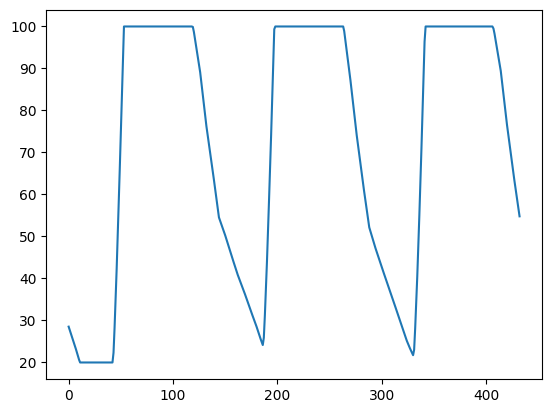

In [5]:
len(observations)

433

Vamos a checkear los datasets. 
Cuántos días de radiación dispongo? Cuántos días de consumo dispongo?

In [ ]:
df = pd.read_csv("environments/Data/EMS/CCALAN.csv")
df = df.ffill()
#df = df.ffill()

Fecha Hora (YYYY-MM-DD HH:MM)                        0
Radiación Solar Global en Seguimiento [mean,W/m2]    0
Radiación Solar Difusa en Seguimiento [mean,W/m2]    0
Radiación Solar Global Horizontal [mean,W/m2]        0
Temperatura [mean,C]                                 0
Humedad Relativa [mean,%]                            0
Velocidad de viento en 4.0 metros [mean,m/s]         0
Voltaje Bateria [mean,V]                             1
Radiación Directa Normal (estimado) [mean,W/m2]      8
Velocidad de viento en 4.0 metros [min,m/s]          8
Velocidad de viento en 4.0 metros [max,m/s]          8
dtype: int64


In [ ]:
def get_sept_to_jan(df:pd.DataFrame):
    # Convert the date column to datetime
    df = df.copy()
    df['Fecha Hora (YYYY-MM-DD HH:MM)'] = pd.to_datetime(df['Fecha Hora (YYYY-MM-DD HH:MM)'])
    # Extract month
    months = df['Fecha Hora (YYYY-MM-DD HH:MM)'].dt.month
    # September (9) to January (1), including both
    mask = (months >= 9) | (months <= 1)
    df = df[mask]
    return df

df_sept_to_jan = get_sept_to_jan(df)

# Enumerate how many seasons are in the data (September to January is one "season" per year)
def get_seasons(df):
    # Group by year, where season is from September (year N) to January (year N+1)
    df = df.copy()
    df['year'] = df['Fecha Hora (YYYY-MM-DD HH:MM)'].dt.year
    df['month'] = df['Fecha Hora (YYYY-MM-DD HH:MM)'].dt.month
    # For months Sep-Dec, season is the current year; for Jan, season is previous year
    df['season'] = np.where(df['month'] == 1, df['year'] - 1, df['year'])
    seasons = df['season'].unique()
    return np.sort(seasons)

seasons = get_seasons(df_sept_to_jan)
print(f"Number of seasons: {len(seasons)}")
print(f"Seasons: {seasons}")

# Function to select data from a certain season
def select_season(df, season):
    df = df.copy()
    df['year'] = df['Fecha Hora (YYYY-MM-DD HH:MM)'].dt.year
    df['month'] = df['Fecha Hora (YYYY-MM-DD HH:MM)'].dt.month
    df['season'] = np.where(df['month'] == 1, df['year'] - 1, df['year'])
    return df[df['season'] == season]

# Example usage:
df_season_2013 = select_season(df_sept_to_jan, 2013)

Number of seasons: 8
Seasons: [2013 2014 2015 2016 2017 2018 2019 2021]


In [4]:
fig = px.line(df_season_2013, x='Fecha Hora (YYYY-MM-DD HH:MM)', y='Radiación Directa Normal (estimado) [mean,W/m2]', title='Radiación Directa Normal (estimado) [mean,W/m2] - Temporada 2015')
fig.show()

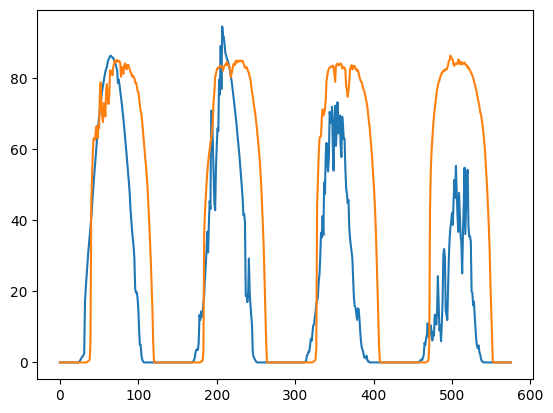

In [ ]:
year = np.random.randint(2013,2019) # select a random year from [0,7]
n_days = 150 
s_day_1 = np.random.randint(0,n_days)
s_day_2 = np.random.randint(0,n_days)

data = select_season(df_sept_to_jan, year)
rad_1 = data["Radiación Directa Normal (estimado) [mean,W/m2]"][s_day_1*144:s_day_1*144+144*4].values
rad_2 = data["Radiación Directa Normal (estimado) [mean,W/m2]"][s_day_2*144:s_day_2*144+144*4].values

temp_1 = data["Temperatura [mean,C]"][s_day_1*144:s_day_1*144+144*4].values
temp_2 = data["Temperatura [mean,C]"][s_day_2*144:s_day_2*144+144*4].values
alpha = np.random.rand()*0.2

rad = rad_1*alpha + rad_2*(1-alpha)
temp = temp_1*alpha + temp_2*(1-alpha)

p_pv = solar_power(rad, temp)

t = np.arange(144*4)
plt.plot(solar_power(get_rad(), get_temperatura())[0:144*4])
plt.plot(p_pv)

In [201]:
from environments.EMS_env import MicrogridEnv

In [202]:
mg_env = MicrogridEnv(1)

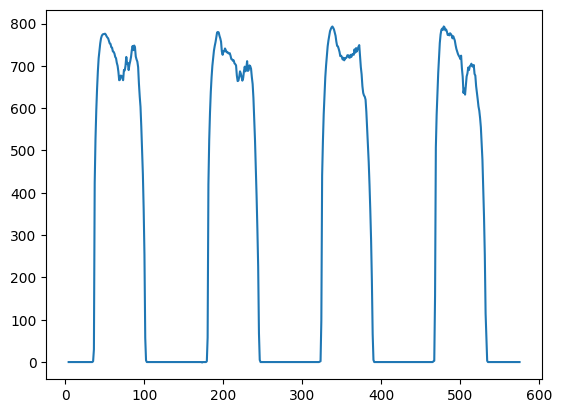

In [38]:
plt.plot(rad.values)

In [44]:
n_nans_rad = rad.isna().sum()
print(f"Number of NaNs in rad: {n_nans_rad}")

Number of NaNs in rad: 8


In [40]:
144*4

576

In [8]:
s_day_1

47

[]

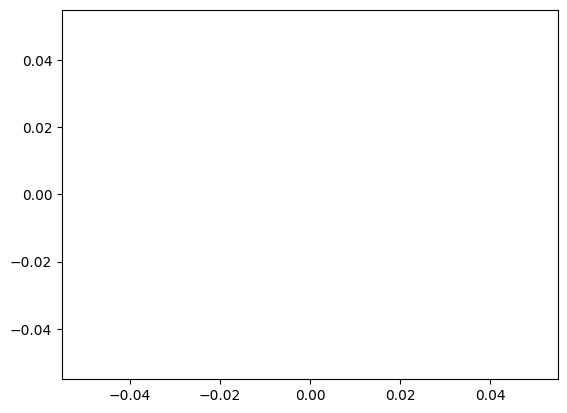

In [7]:
plt.plot()